In [1]:
# Reinforcement Learning - Pekiştirmeli Öğretim

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
pip install gym gymnasium

Note: you may need to restart the kernel to use updated packages.


In [4]:
import gymnasium as gym

In [5]:
env=gym.make('FrozenLake-v1'), is_slippery=False, render_mode='rgb_array')
import matplotlib.pyplot as plt
state=env.reset()
img=env.render()
plt.imshow

SyntaxError: unmatched ')' (2554848875.py, line 1)

In [ ]:
import gymnasium as gym
import matplotlib.pyplot as plt

env = gym.make('FrozenLake-v1', is_slippery=False, render_mode="rgb_array")

state, info = env.reset()

img = env.render()

plt.imshow(img)
plt.axis("off")
plt.show()


In [ ]:
# =========================
# FrozenLake (Gymnasium) - Tek Hücre Çözüm
# - Gerekli paketleri kurar (gymnasium, pygame / toy-text)
# - FrozenLake env oluşturur
# - Render (rgb_array) ile görüntüyü matplotlib'te gösterir
# - pygame kurulamazsa: render kapalı devam eder ve uyarı basar
# =========================

import sys
import subprocess
import importlib

def pip_install(pkg: str):
    print(f"\n[INSTALL] {pkg}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

def ensure_import(module_name: str, pip_name: str = None) -> bool:
    """Module import edilemiyorsa pip ile kurmayı dener. Başarırsa True."""
    try:
        importlib.import_module(module_name)
        print(f"[OK] {module_name} hazır.")
        return True
    except ModuleNotFoundError:
        print(f"[MISSING] {module_name} yok. Kurmayı deniyorum...")
        try:
            pip_install(pip_name or module_name)
            importlib.invalidate_caches()
            importlib.import_module(module_name)
            print(f"[OK] {module_name} kuruldu ve hazır.")
            return True
        except Exception as e:
            print(f"[FAIL] {module_name} kurulamadı: {e}")
            return False

# 1) Temel paketler
ensure_import("gymnasium", "gymnasium")
ensure_import("matplotlib", "matplotlib")

import gymnasium as gym
import matplotlib.pyplot as plt

# 2) pygame / toy-text bağımlılığı (render için gerekli)
# Önce pygame'i direkt dene; olmazsa toy-text extras'ı dene
pygame_ok = ensure_import("pygame", "pygame")
if not pygame_ok:
    # gymnasium[toy-text] pygame'i de getirir
    print("\n[INFO] pygame yok -> gymnasium[toy-text] kurulumu deneniyor...")
    try:
        pip_install('gymnasium[toy-text]')
        importlib.invalidate_caches()
        pygame_ok = ensure_import("pygame", "pygame")
    except Exception as e:
        print(f"[FAIL] gymnasium[toy-text] kurulamadı: {e}")
        pygame_ok = False

# 3) Ortamı oluştur + reset + (mümkünse) render
# pygame varsa rgb_array ile görsel al. Yoksa render_mode olmadan devam et.
if pygame_ok:
    env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
    state, info = env.reset()
    img = env.render()
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.title("FrozenLake (rgb_array)")
    plt.show()
    print("\n[SUCCESS] Render tamam. state:", state, "| info:", info)
else:
    print("\n[WARN] pygame kurulamadı. Render kapalı devam ediyorum (eğitim/deneme için yeterli).")
    env = gym.make("FrozenLake-v1", is_slippery=False)  # render_mode yok
    state, info = env.reset()
    print("[OK] Env hazır. state:", state, "| info:", info)

# 4) Bonus: kısa bir random rollout (env çalışıyor mu diye)
print("\n--- Random rollout (10 adım) ---")
terminated = truncated = False
total_reward = 0.0

for t in range(10):
    if terminated or truncated:
        state, info = env.reset()
        terminated = truncated = False

    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    print(f"t={t:02d} | s={state} -> a={action} -> s'={next_state} | r={reward} | done={terminated or truncated}")
    state = next_state

print("\n[DONE] Toplam ödül:", total_reward)


In [ ]:
next_state, reward, terminated, truncated, info=env.step(action)

In [ ]:
print(next_state, reward, terminated, truncated, info)

In [ ]:
import numpy as np
import gym

# Create the Taxi environment
env = gym.make("Taxi-v3")
q_table = np.zeros([env.observation_space.n, env.action_space.n])
alpha = 0.8
gamma = 0.9
epsilon = 0.1

for episode in range(1000):
    state = env.reset()
    done = False
    
    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(q_table[state])  # Exploit
        
        next_state, reward, done, _ = env.step(action)
        q_table[state, action] += alpha * (reward + gamma * np.max(q_table[next_state]) - q_table[state, action])
        state = next_state

print("Trained Q-table for Taxi:\n", q_table)
04:01:52	Zafer Acar:	env = gym.make("Taxi-v3")
state = env.reset()
img = env.render(mode='rgb_array')

plt.imshow(img)
plt.title("Taxi")
plt.axis('off')
plt.show()
04:03:16	fatma yüzseven:	IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indice bu ahata nednedir
04:04:01	Huseyin YILMAZ:	import numpy as np
import gym

# Create the Taxi environment
env = gym.make("Taxi-v3")
q_table = np.zeros([env.observation_space.n, env.action_space.n])
alpha = 0.8
gamma = 0.9
epsilon = 0.1

for episode in range(1000):
    # FIX 1: Unpack the tuple returned by reset
    state, info = env.reset()
    done = False
    
    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample() 
        else:
            action = np.argmax(q_table[state]) 
        
        # FIX 2: Unpack 5 values (new API) instead of 4
        next_state, reward, terminated, truncated, info = env.step(action)
        
        # Combine terminated and truncated into a single 'done' flag
        done = terminated or truncated

        q_table[state, action] += alpha * (reward + gamma * np.max(q_table[next_state]) - q_table[state, action])
        state = next_state

print("Trained Q-table for Taxi:\n", q_table)



In [ ]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

# 1) Env (render için doğru yöntem)
env = gym.make("Taxi-v3", render_mode="rgb_array")

# 2) Q-table
q_table = np.zeros((env.observation_space.n, env.action_space.n))

# 3) Hyperparams
alpha = 0.8
gamma = 0.9
epsilon = 0.1
episodes = 5000

# 4) Train
for episode in range(episodes):
    state, info = env.reset()
    done = False

    while not done:
        # epsilon-greedy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(q_table[state]))

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-update
        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state

print("Training bitti. Q-table shape:", q_table.shape)

# 5) Test + Render (tek kare)
state, info = env.reset()
img = env.render()

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Taxi-v3 (Start Frame)")
plt.axis("off")
plt.show()


In [ ]:
# Q learning 

In [ ]:
np.save('frozenlake.npy',Q_table)

In [ ]:
# =========================
# "Evriz / chat log" içindeki timestamp'leri temizle ve Taxi Q-learning'i çalıştır
# =========================

import re
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt

raw_text = r"""
import numpy as np
import gym

# Create the Taxi environment
env = gym.make("Taxi-v3")
q_table = np.zeros([env.observation_space.n, env.action_space.n])
alpha = 0.8
gamma = 0.9
epsilon = 0.1

for episode in range(1000):
    state = env.reset()
    done = False
    
    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(q_table[state])  # Exploit
        
        next_state, reward, done, _ = env.step(action)
        q_table[state, action] += alpha * (reward + gamma * np.max(q_table[next_state]) - q_table[state, action])
        state = next_state

print("Trained Q-table for Taxi:\n", q_table)
04:01:52	Zafer Acar:	env = gym.make("Taxi-v3")
state = env.reset()
img = env.render(mode='rgb_array')

plt.imshow(img)
plt.title("Taxi")
plt.axis('off')
plt.show()
04:03:16	fatma yüzseven:	IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indice bu ahata nednedir
04:04:01	Huseyin YILMAZ:	import numpy as np
"""

# 1) Timestamp ile başlayan satırları ve chat isimlerini temizle
#    Örn: "04:01:52  Zafer Acar:  env = ..." -> "env = ..."
clean_lines = []
for line in raw_text.splitlines():
    line = line.rstrip()

    # 04:01:52 ... gibi başlayan satırları yakala
    m = re.match(r"^\s*\d{2}:\d{2}:\d{2}\s+[^:]+:\s*(.*)$", line)
    if m:
        line = m.group(1)  # sadece kod kısmını al

    # Timestamp satırında kod yoksa (sadece yorum/sohbet) tamamen at
    if re.match(r"^\s*\d{2}:\d{2}:\d{2}\b", line):
        continue

    # Boş değilse ekle
    clean_lines.append(line)

clean_text = "\n".join(clean_lines)

# 2) gym yerine gymnasium kullanımı için küçük uyarlama
#    (Çünkü yeni API reset/step dönüşleri farklı)
clean_text = clean_text.replace("import gym", "import gymnasium as gym")

# 3) Eski API kullanan kısımları yeni API'ye çevir (state=env.reset() gibi)
#    - reset(): state, info
#    - step(): next_state, reward, terminated, truncated, info
clean_text = clean_text.replace("state = env.reset()", "state, info = env.reset()")
clean_text = clean_text.replace("next_state, reward, done, _ = env.step(action)",
                                "next_state, reward, terminated, truncated, info = env.step(action)\n        done = terminated or truncated")

# 4) Render satırlarını da gymnasium uyumlu yap:
#    env = gym.make(..., render_mode="rgb_array") kullanmak daha doğru.
#    Eğer clean_text içinde env = gym.make("Taxi-v3") varsa render_mode ekleyelim.
clean_text = re.sub(r'env\s*=\s*gym\.make\("Taxi-v3"\)',
                    'env = gym.make("Taxi-v3", render_mode="rgb_array")',
                    clean_text)

# 5) Eğer plt importu yoksa ekle
if "import matplotlib.pyplot as plt" not in clean_text:
    clean_text = "import matplotlib.pyplot as plt\n" + clean_text

print("---- TEMİZLENMİŞ VE DÜZELTİLMİŞ KOD (özet) ----")
print("\n".join(clean_text.splitlines()[:40]))
print("...\n")

# 6) Temiz kodu çalıştır
exec(clean_text)

# 7) Eğitim sonrası tek kare render göster
# (env render_mode rgb_array ise img = env.render() yeterli)
img = env.render()
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title("Taxi-v3 (Render)")
plt.show()




In [ ]:
import numpy as np
import gym

# Create the Taxi environment
env = gym.make("Taxi-v3")
q_table = np.zeros([env.observation_space.n, env.action_space.n])
alpha = 0.8
gamma = 0.9
epsilon = 0.1

for episode in range(1000):
    # FIX 1: Unpack the tuple returned by reset
    state, info = env.reset()
    done = False
    
    while not done:
        if np.random.rand() < epsilon:
            action = env.action_space.sample() 
        else:
            action = np.argmax(q_table[state]) 
        
        # FIX 2: Unpack 5 values (new API) instead of 4
        next_state, reward, terminated, truncated, info = env.step(action)
        
        # Combine terminated and truncated into a single 'done' flag
        done = terminated or truncated

        q_table[state, action] += alpha * (reward + gamma * np.max(q_table[next_state]) - q_table[state, action])
        state = next_state

print("Trained Q-table for Taxi:\n", q_table)
04:04:40	Zafer Acar:	env = gym.make("Taxi-v3")
state = env.reset()
img = env.render(mode='rgb_array')

plt.imshow(img)
plt.title("Taxi")
plt.axis('off')
plt.show()



In [ ]:
# =========================
# FrozenLake Q-Learning (Gymnasium)
# - Train
# - Save Q-table (.pkl ve .npy)
# - Load & Visualize (heatmap)
# - (Opsiyonel) Policy run + render (pygame varsa)
# =========================

import sys, subprocess, importlib

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# --- Kurulum (gerekliyse) ---
# seaborn + matplotlib görselleştirme için
# gymnasium[toy-text] FrozenLake + pygame bağımlılıklarını daha sorunsuz kurar
try:
    import gymnasium
except Exception:
    pip_install("gymnasium")
try:
    import seaborn
except Exception:
    pip_install("seaborn")
try:
    import matplotlib
except Exception:
    pip_install("matplotlib")
# FrozenLake render için pygame gerekebilir (kurulamazsa sorun değil)
try:
    import pygame
except Exception:
    try:
        pip_install('gymnasium[toy-text]')
    except Exception:
        pass

import numpy as np
import gymnasium as gym
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) ENV (Render güvenli)
# -------------------------
# pygame varsa rgb_array ile render alırız, yoksa render kapalı devam ederiz
def make_env():
    try:
        env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
        _ = env.reset()
        _ = env.render()  # gerçekten render çalışıyor mu test
        print("[OK] render_mode='rgb_array' aktif (pygame var).")
        return env, True
    except Exception as e:
        print("[WARN] rgb_array render aktif edilemedi (pygame yok olabilir). Render kapalı devam ediyorum.")
        env = gym.make("FrozenLake-v1", is_slippery=False)  # render_mode yok
        return env, False

env, can_rgb_render = make_env()

state_size = env.observation_space.n
action_size = env.action_space.n

# -------------------------
# 2) Q-table + Hyperparams
# -------------------------
Q_table = np.zeros((state_size, action_size))

alpha = 0.1          # learning rate
gamma = 0.99         # discount
epsilon = 1.0        # exploration rate (başlangıç)
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 20000     # hocadaki gibi yüksek tutabilirsin
max_steps = 100      # her episode max adım

# -------------------------
# 3) TRAIN
# -------------------------
rewards_per_episode = []

for episode in range(episodes):
    state, info = env.reset()
    done = False
    total_reward = 0.0

    for step in range(max_steps):
        # epsilon-greedy
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q_table[state]))

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-learning update
        Q_table[state, action] += alpha * (
            reward + gamma * np.max(Q_table[next_state]) - Q_table[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    # epsilon decay
    epsilon = max(epsilon * epsilon_decay, epsilon_min)
    rewards_per_episode.append(total_reward)

print("[DONE] Training completed.")

# -------------------------
# 4) SAVE (PKL + NPY)
# -------------------------
with open("qtable_frozenlake.pkl", "wb") as f:
    pickle.dump(Q_table, f)

np.save("frozenlake.npy", Q_table)

print("[SAVED] qtable_frozenlake.pkl ve frozenlake.npy kaydedildi.")

# -------------------------
# 5) LOAD (kontrol amaçlı)
# -------------------------
with open("qtable_frozenlake.pkl", "rb") as f:
    Q_loaded = pickle.load(f)

print("[CHECK] Q_loaded shape:", Q_loaded.shape)

# -------------------------
# 6) VISUALIZE: Q-table Heatmap
# -------------------------
plt.figure(figsize=(10, 6))
sns.heatmap(Q_loaded, annot=True, fmt=".2f", cbar=True)
plt.title("FrozenLake Q-Table Heatmap (states x actions)")
plt.xlabel("Action")
plt.ylabel("State")
plt.show()

# -------------------------
# 7) Training reward trend (opsiyonel)
# -------------------------
# Son 2000 episode ortalamasını görmek daha anlamlı
window = 500
if len(rewards_per_episode) >= window:
    moving_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode="valid")
    plt.figure(figsize=(10,4))
    plt.plot(moving_avg)
    plt.title(f"Moving Average Reward (window={window})")
    plt.xlabel("Episode")
    plt.ylabel("Avg Reward")
    plt.show()

# -------------------------
# 8) POLICY RUN + RENDER (pygame varsa)
# -------------------------
print("\n--- Policy run (greedy) ---")
state, info = env.reset()
done = False

for t in range(30):
    action = int(np.argmax(Q_loaded[state]))
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    # Render mümkünse bir kare göster
    if can_rgb_render:
        img = env.render()
        plt.figure(figsize=(3,3))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"t={t}, s={state}, a={action}, r={reward}")
        plt.show()
    else:
        # Render yoksa sadece text log bas
        print(f"t={t:02d} | s={state} -> a={action} -> s'={next_state} | r={reward} | done={done}")

    state = next_state
    if done:
        print("Episode finished. Reward:", reward)
        break

env.close()



In [ ]:
np.save('frozenlake.npy',Q_table)

In [ ]:
print(Q_table)

In [ ]:
import seaborn as sns

In [ ]:
import numpy as np
import gymnasium as gym

env = gym.make("FrozenLake-v1", is_slippery=False)  # önce kolay mod
Q = np.zeros((env.observation_space.n, env.action_space.n))

alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.999   # daha yavaş düşür (kritik!)
epsilon_min = 0.1       # 0.01 yerine 0.1 bırak (kritik!)
episodes = 50000
max_steps = 200

success = 0

for ep in range(episodes):
    state, info = env.reset()
    done = False

    for _ in range(max_steps):
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q[state]))

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        Q[state, action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state, action])
        state = next_state

        if done:
            # FrozenLake'de hedefe ulaştıysan reward genelde 1 olur
            if reward > 0:
                success += 1
            break

    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    # Her 5000 episode'da bir rapor
    if (ep + 1) % 5000 == 0:
        nonzero = np.count_nonzero(Q)
        print(f"ep={ep+1} | success={success} | success_rate={success/(ep+1):.4f} | epsilon={epsilon:.3f} | nonzeroQ={nonzero}")

print("Final nonzero Q:", np.count_nonzero(Q))


In [ ]:
np.save('frozenlake.npy',Q_table)

In [ ]:
print(Q_table)


ep=5000 | success=3625 | rate=0.725 | eps=0.100 | nonzero=35 | maxQ=1.000000
ep=10000 | success=8113 | rate=0.811 | eps=0.100 | nonzero=35 | maxQ=1.000000
ep=15000 | success=12610 | rate=0.841 | eps=0.100 | nonzero=35 | maxQ=1.000000
ep=20000 | success=17110 | rate=0.856 | eps=0.100 | nonzero=35 | maxQ=1.000000
ep=25000 | success=21536 | rate=0.861 | eps=0.100 | nonzero=35 | maxQ=1.000000
ep=30000 | success=26015 | rate=0.867 | eps=0.100 | nonzero=35 | maxQ=1.000000
ep=35000 | success=30522 | rate=0.872 | eps=0.100 | nonzero=35 | maxQ=1.000000
ep=40000 | success=34970 | rate=0.874 | eps=0.100 | nonzero=35 | maxQ=1.000000
ep=45000 | success=39427 | rate=0.876 | eps=0.100 | nonzero=35 | maxQ=1.000000
ep=50000 | success=43904 | rate=0.878 | eps=0.100 | nonzero=35 | maxQ=1.000000

--- FINAL CHECK ---
nonzero: 35
max: 0.9999999999999996
min_nonzero: 0.36922759049497894
[SAVED] qtable_f1.pkl + frozenlake.npy

Q_table:
 [[0.94148  0.932065 0.95099  0.94148 ]
 [0.94148  0.       0.960596 0.950

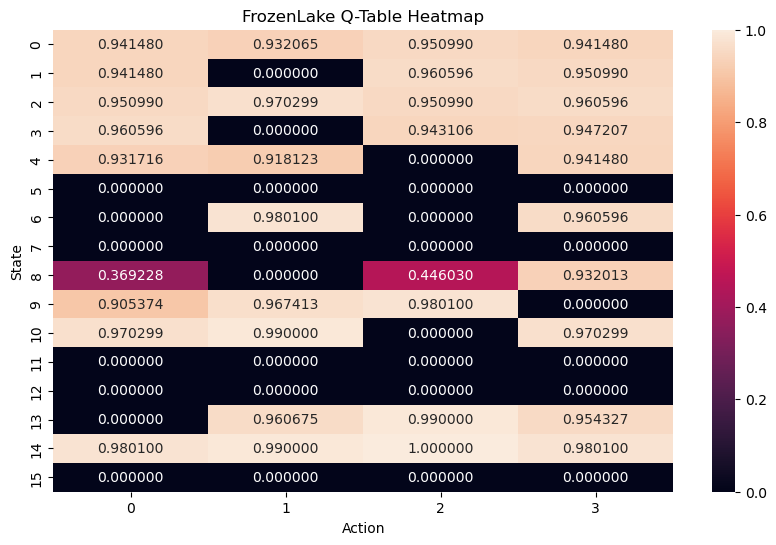

In [7]:
import numpy as np
import gymnasium as gym
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Env
env = gym.make("FrozenLake-v1", is_slippery=False)   # önce kolay mod
state_size = env.observation_space.n
action_size = env.action_space.n

# 2) Q-table
Q_table = np.zeros((state_size, action_size), dtype=np.float64)

# 3) Hyperparams
alpha = 0.1
gamma = 0.99
epsilon = 1.0
epsilon_decay = 0.999   # kritik: yavaş düşür
epsilon_min = 0.1       # kritik: keşfi erken bitirme
episodes = 50000
max_steps = 200

success = 0

# 4) Train
for ep in range(episodes):
    state, info = env.reset()
    done = False

    for _ in range(max_steps):
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = int(np.argmax(Q_table[state]))

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        Q_table[state, action] += alpha * (
            reward + gamma * np.max(Q_table[next_state]) - Q_table[state, action]
        )

        state = next_state

        if done:
            if reward > 0:
                success += 1
            break

    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    if (ep + 1) % 5000 == 0:
        print(f"ep={ep+1} | success={success} | rate={success/(ep+1):.3f} | eps={epsilon:.3f} | nonzero={np.count_nonzero(Q_table)} | maxQ={Q_table.max():.6f}")

env.close()

# 5) Kesin kontrol (buraya bak!)
print("\n--- FINAL CHECK ---")
print("nonzero:", np.count_nonzero(Q_table))
print("max:", Q_table.max())
print("min_nonzero:", Q_table[Q_table != 0].min() if np.count_nonzero(Q_table) else None)

# 6) Save
with open("qtable_f1.pkl", "wb") as f:
    pickle.dump(Q_table, f)
np.save("frozenlake.npy", Q_table)
print("[SAVED] qtable_f1.pkl + frozenlake.npy")

# 7) Print (daha net)
np.set_printoptions(precision=6, suppress=False)
print("\nQ_table:\n", Q_table)

# 8) Heatmap (ondalıkları net göster)
plt.figure(figsize=(10, 6))
sns.heatmap(Q_table, annot=True, fmt=".6f", cbar=True)
plt.title("FrozenLake Q-Table Heatmap")
plt.xlabel("Action")
plt.ylabel("State")
plt.show()



In [8]:
import seaborn as sns

<Axes: >

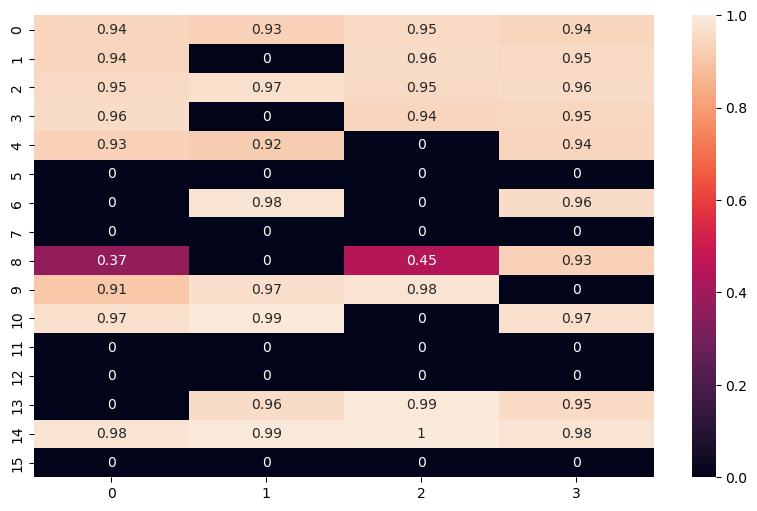

In [9]:
plt.figure(figsize=(10,6))
sns.heatmap(Q_table, annot=True)

In [10]:
import gymnasium as gym
import time

env=gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')

state,_ =env.reset()
done=False
total_reward=0
t=0
while not done:
    time.sleep(0.5)
    action=np.argmax(Q_table[state])
    state,reward,terminated,truncated,info=env.step(action)
    done=terminated or truncated
    total_reward+=reward

env.close()
print('total reward: ',total_reward)
env.close()
print('total reward: ',total_reward)

total reward:  1
total reward:  1


In [11]:
# Bellman Equation

In [12]:
# Derin ögrenme ile reinforcement learning DQN Deep Q learning

In [14]:
pip install gymnasium stable-baselines3[extra] torch

   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   --------------- ------------------------ 1.3/3.5 MB 6.2 MB/s eta 0:00:01
   --------------------------------- ------ 2.9/3.5 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 6.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [ale-py]
   -------------------- ------------------- 1/2 [stable-baselines3]
   -------------------- ------------------- 1/2 [stable-baselines3]
   -------------------- ------------------- 1/2 [stable-baselines3]
   -------------------- ------------------- 1/2 [stable-baselines3]
   -------------------- ------------------- 1/2 [stable-baselines3]
   -------------------- ------------------- 1/2 [stable-baselines3]
   -------------------- ------------------- 1/2 [stable-baselines3]
   -------------------- ------------------- 1/2 [stable-baselines3]
   -------------------- ------------------- 1/2 [stable-baselines3]
   -------------------- ------------

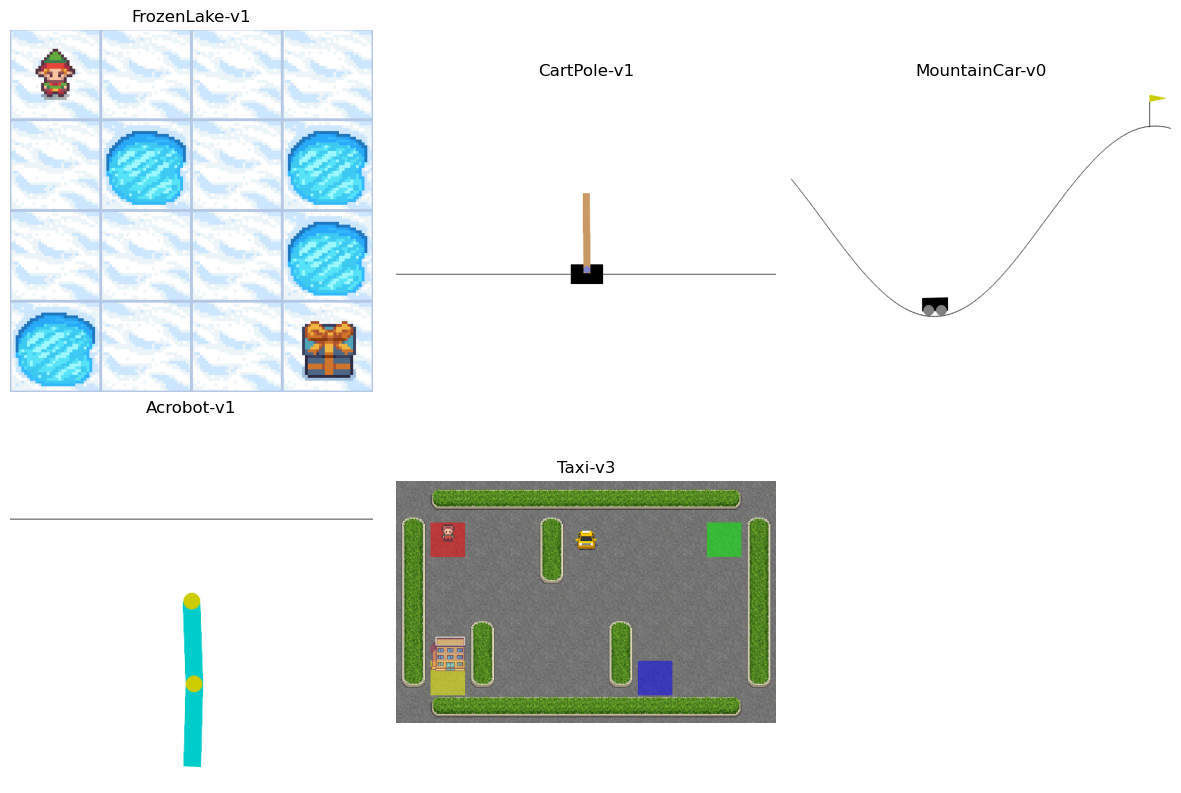

In [15]:
import gymnasium as gym
import matplotlib.pyplot as plt

examples = ["FrozenLake-v1","CartPole-v1","MountainCar-v0","Acrobot-v1","Taxi-v3"]

plt.figure(figsize=(12,8))

for i,name in enumerate(examples):
    env = gym.make(name, render_mode="rgb_array")
    env.reset()
    img = env.render()

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

# 1️⃣ Environment
env = gym.make("CartPole-v1")
env = Monitor(env)  # eğitim istatistikleri için

# 2️⃣ Model Tanımı (DQN)
model = DQN(
    policy="MlpPolicy",
    env=env,
    learning_rate=1e-3,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=64,
    gamma=0.99,
    train_freq=4,
    target_update_interval=1000,
    exploration_fraction=0.1,
    exploration_final_eps=0.02,
    verbose=1,
)

# 3️⃣ Eğit
model.learn(total_timesteps=50_000)

# 4️⃣ Kaydet
model.save("cartpole_dqn")

print("Model kaydedildi.")

# 5️⃣ Performans Ölç
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=20)
print(f"Ortalama ödül: {mean_reward:.2f} ± {std_reward:.2f}")

env.close()


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 26.2     |
|    ep_rew_mean      | 26.2     |
|    exploration_rate | 0.979    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 14995    |
|    time_elapsed     | 0        |
|    total_timesteps  | 105      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 22.9     |
|    ep_rew_mean      | 22.9     |
|    exploration_rate | 0.964    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 15263    |
|    time_elapsed     | 0        |
|    total_timesteps  | 183      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 25.5     |
|    ep_rew_mean      | 25.5     |
|    exploration_rate | 0.94     |
| t